This file demonstrates the implementation of SHARV and ASHARV from my paper: A Simple Joint Model of Returns, Volatility and Volatility of Volatility,
Journal of Econometrics, 2023

The two models I proposed are called Stochastic Heteroskedastic AutoRegressive Volatility (SHARV) model and its asymmetric extension ASHARV model

In [1]:
%load_ext autoreload
%autoreload 2
from SHARV_class import *
from Utilities import *
import matplotlib.pyplot as plt
from arch import arch_model
import statsmodels.api as sm
import pandas as pd
from forecast_funcs import *


In [2]:
data = pd.read_excel('Data/DJI.xlsx')
data['Date'] = pd.to_datetime(data['Date'], unit='D', origin='1899-12-30')
data.set_index('Date', inplace=True)

data = data.dropna()
# Log return
data['Close'] = np.log(data['Close']).diff() * 100

y = data[['Close']].dropna()

Using Dow Jones daily return as an example, convert the data to log return in percentage for numerical convenience. The maximum likelihood procedure is implemented in Cython file loglike.pyx, which utilizes C maths for the calculation. Please compile and set up accordingly (see read me)

The Sharv model is defined as:
$$\begin{align}
    &r_t = \sigma_t\epsilon_t, \\
    &\sigma_t^2 = \beta \sigma_{t-1}^2   + (\alpha + \psi\sigma_{t-1}^2) \epsilon_t^2,
\end{align}$$
where $\epsilon_t$ are i.i.d. $(0, 1)$

While the asymmetric extension ASHARV is given by:
$$\begin{align}
    &r_t = \mu\sigma_{t-1} + \sigma_t\epsilon_t, \\
    &\sigma_t^2 = \beta \sigma_{t-1}^2 + (\alpha + \psi\sigma_{t-1}^2)\epsilon_t^2 + (\omega + \phi\sigma_{t-1}^2)(\epsilon_t^{-})^2,
\end{align}$$
where $x^- = \min(x, 0)$.

We will use $\epsilon \sim N(0, 1)$ for parameter estimation purposes. Even if the true $\epsilon_t$ are not Normal, the standard quasi maximum likelihood (QML) theory states that the parameter estimators are still consistent under mild conditions

In [3]:
# Fit the sharv model
sharv_res = Sharv(y).fit()
# Asymmetric version
asharv_res = Sharv(y, asymmetry=True).fit()
# Benchmark model
garch = arch_model(y, mean="Zero", p=1, o=0, q=1).fit(disp=0)

print(sharv_res.summary())
print(asharv_res.summary())
print(garch.summary())

  Stochastic Heteroskedastic AutoRegressive Volatility Model Results  
Dep. Variable:    y                Model:           Quasi-ML          
No. Observations: 5283             Log-Likelihood:  -6974.2697        
Date:             Sat, 07 Mar 2026 BIC:             13974.2561        
           coef   std err         t     P>|t|    [0.025    0.975]
-----------------------------------------------------------------
beta     0.8764    0.0085   102.521     0.000     0.860     0.893
alpha    0.0132    0.0027     4.973     0.000     0.008     0.018
psi      0.1101    0.0091    12.030     0.000     0.092     0.128
-----------------------------------------------------------------
Asymmetric Stochastic Heteroskedastic AutoRegressive Volatility Model Results
Dep. Variable:    y                Model:           Quasi-ML          
No. Observations: 5283             Log-Likelihood:  -6823.0260        
Date:             Sat, 07 Mar 2026 BIC:             13697.4855        
           coef   std err    

Next, I will show that even with $\epsilon_t \sim N(0, 1)$, the conditional density of $r_t$ still has fat tails and skewness (under ASHARV)
Recall the conditional density of (A)SHARV is given by:
$$    f_r(y|\mathcal{F}_{t-1}) = \frac{y}{d_1(y, \sigma_{t-1}^2; \theta)d_2(y, \sigma_{t-1}^2; \theta)} f_\epsilon\big(d_2(y, \sigma_{t-1}^2; \theta)\big), \ \text{for $y \neq 0$}$$
where
$$    d_1(y, \sigma_{t-1}^2; \theta) = \sqrt{b_{t-1}^2+4a_{t-1}y^2+4c_{t-1}(y^-)^2},$$
$$    d_2(y, \sigma_{t-1}^2; \theta) =
    \begin{cases}
    sign(y)\sqrt{\dfrac{d_1(y, \sigma_{t-1}^2; \theta)-b_{t-1}}{2a_{t-1}+2c_{t-1}1_{(y<0)}}}, \ \ \ \text{if $(\alpha, \psi, \omega, \phi)^{'} \neq 0$} \\
    \ y/\sqrt{b_{t-1}},\ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \    \text{if $(\alpha, \psi, \omega, \phi)^{'} = 0$}
    \end{cases}$$ and $\tilde{r}_t = r_t -\mu\sigma_{t-1} $, $a_t = \alpha+\psi\sigma_t^2$, $b_t=\beta\sigma_t^2$ and $c_t = \omega+\phi\sigma_t^2$

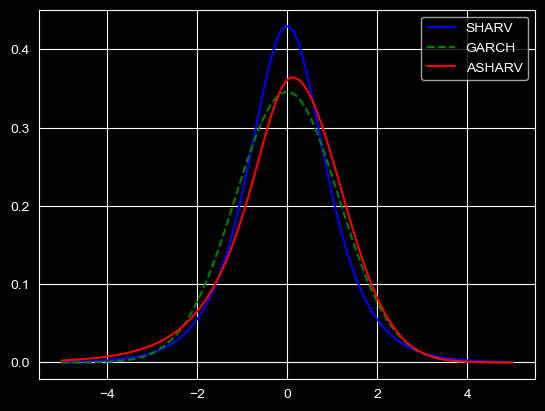

In [4]:
sharv_pdf = np.vectorize(lambda x: pdf_sharv(sharv_res.params, x, model='SHARV'))
garch_pdf = np.vectorize(lambda x: pdf_sharv([garch.params['omega'], garch.params['beta[1]'],
                                              garch.params['alpha[1]']], x, model='GARCH'))
# Notice that for ASHARV, even with symmetric normal innovation, the conditional density is left skewed with fatter
# left tail, which captures stylized facts of financial returns
asharv_pdf = np.vectorize(lambda x: pdf_sharv(asharv_res.params, x, model='ASHARV'))
x_ax = np.linspace(-5, 5, 100)
plt.plot(x_ax,sharv_pdf(x_ax), label='SHARV', color='blue')
plt.plot(x_ax,garch_pdf(x_ax), label='GARCH', color='green', linestyle='dashed')
plt.plot(x_ax,asharv_pdf(x_ax), label='ASHARV', color='red')
plt.legend()
plt.show()

Now look at the QQ plot of standardised residuals $\hat{\epsilon}_t$. Notice how SHARV and ASHARV has residuals whose quantiles are almost identical to that of standard normal. To recover Normality from noisy returns has huge implications in terms of economic interpretation. It also means the QML estimator has efficiency close to maximum likelihood.

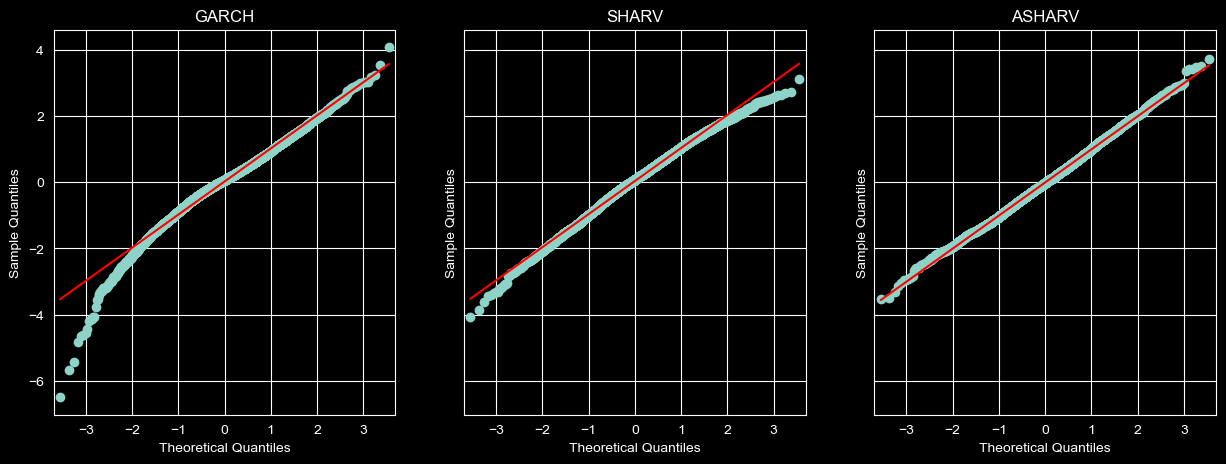

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

sm.qqplot(garch.std_resid, line='s', ax=axes[0])
axes[0].set_title("GARCH")

sm.qqplot(pd.Series(sharv_res.filter()['Standardized residuals']['Standardized residuals']), line='s', ax=axes[1])
axes[1].set_title("SHARV")

sm.qqplot(asharv_res.filter()['Standardized residuals']['Standardized residuals'], line='s', ax=axes[2])
axes[2].set_title("ASHARV")

plt.show()

Now compare the volatility nowcast, or filter. Since the true volatility is not observed. I use the daily realized volatility RV from 5-min returns as proxy since the RV converges to Integrated Volatility (IV) in the limit. Use the mean squared error and QLIKE loss function as metrix. MSE is highly sensitive to outliers which volatility models are notorious for. Hence, QLIKE is a more robust loss metric when comparing volatility performance

In [6]:
# Compare the volatility estimation with realized volatility (RV). RV for DJIA is obtained from a high frequency trading
# platform
RV = pd.read_excel('Data/rv_dj.xlsx')
RV['Date'] = pd.to_datetime(RV['DateTime'], unit='D', origin='1899-12-30')
RV.set_index('Date', inplace=True)
RV = np.sqrt(RV['Return'])

In [7]:
sharv_vol = sharv_res.filter()
asharv_vol = asharv_res.filter()
garch_vol = garch.conditional_volatility
combined_vol = pd.concat([sharv_vol['Volatility'], asharv_vol['Volatility'], garch_vol, RV], axis=1)
combined_vol.columns = ['SHARV', 'ASHARV', 'GARCH', 'RV']
combined_vol = combined_vol.dropna()

In [8]:
# Compute MSE for each model column
mse_values = ((combined_vol[['SHARV', 'ASHARV', 'GARCH']].subtract(combined_vol['RV'], axis=0))**2).mean()

# Convert results into a new DataFrame
mse_df = pd.DataFrame(mse_values, columns=['MSE'])
mse_df

,MSE
SHARV,0.093574
ASHARV,0.084537
GARCH,0.150620


In [9]:
# QLIKE formula: (y / y_hat) - log(y / y_hat) - 1
ratio = combined_vol[['SHARV', 'ASHARV', 'GARCH']].div(combined_vol['RV'], axis=0).pow(-1) # This is y / y_hat
qlike_values = (ratio - np.log(ratio) - 1).mean()

# 3. Combine into a results DataFrame
qlike_df = pd.DataFrame(qlike_values, columns=['QLIKE'])
qlike_df

,QLIKE
SHARV,0.078720
ASHARV,0.066619
GARCH,0.119889


Note that in both case (A)SHARV produce the lowest loss metrics, indicating superior volatility modelling power

Now look at the out-of-sample forecast. Consider 1-step, 5-step and 10-step forecast. To save time, I test on the last 10% of the data. I rerun parameter estimation every 50 days and use these parameters to estimate the next 50 day volatility

In [10]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

sharv_forecast = pd.concat(out_of_sample(y))
ashatv_forecast = pd.concat(out_of_sample(y, model='ASHARV'))
garch_forecast = pd.concat(out_of_sample(y, model='GARCH'))
# Put all forecast together for comparison
forecast = pd.concat([sharv_forecast, ashatv_forecast, garch_forecast, RV], axis=1)
forecast.columns = ['SHARV', 'ASHARV', 'GARCH', 'RV']
forecast = forecast.dropna()

# Compute MSE for each model column
mse_oos = ((forecast[['SHARV', 'ASHARV', 'GARCH']].subtract(forecast['RV'], axis=0))**2).mean()
mse_oos = pd.DataFrame(mse_oos, columns=['MSE'])
# Compute QLIKE for each model column
ratio = forecast[['SHARV', 'ASHARV', 'GARCH']].div(forecast['RV'], axis=0).pow(-1) # This is y / y_hat
qlike_oos = (ratio - np.log(ratio) - 1).mean()
qlike_oos = pd.DataFrame(qlike_oos, columns=['QLIKE'])
print(mse_oos)
print(qlike_oos)

/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/pytho

             MSE
SHARV   0.112548
ASHARV  0.100891
GARCH   0.140476
           QLIKE
SHARV   0.106482
ASHARV  0.092096
GARCH   0.141003


In [11]:
# 5-step
sharv_forecast_5 = pd.concat(out_of_sample(y, step=5))
asharv_forecast_5 = pd.concat(out_of_sample(y, step=5, model='ASHARV'))
garchforecast_5 = pd.concat(out_of_sample(y, step=5, model='GARCH'))
forecast_5 = pd.concat([sharv_forecast_5, asharv_forecast_5, garchforecast_5], axis=1)
forecast_5 = forecast_5.join(RV, how='left')
forecast_5.columns = ['SHARV', 'ASHARV', 'GARCH', 'RV']
forecast_5 = forecast_5.dropna()

# Compute MSE for each model column
mse_oos_5 = ((forecast_5[['SHARV', 'ASHARV', 'GARCH']].subtract(forecast_5['RV'], axis=0))**2).mean()
mse_oos_5 = pd.DataFrame(mse_oos_5, columns=['MSE'])
# Compute QLIKE for each model column
ratio = forecast_5[['SHARV', 'ASHARV', 'GARCH']].div(forecast_5['RV'], axis=0).pow(-1) # This is y / y_hat
qlike_oos_5 = (ratio - np.log(ratio) - 1).mean()
qlike_oos_5 = pd.DataFrame(qlike_oos_5, columns=['QLIKE'])
print(mse_oos_5)
print(qlike_oos_5)

/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/pytho

             MSE
SHARV   0.132615
ASHARV  0.126390
GARCH   0.155826
           QLIKE
SHARV   0.121764
ASHARV  0.111740
GARCH   0.152026


In [12]:
# 10-step
sharv_forecast_10 = pd.concat(out_of_sample(y, step=10))
asharv_forecast_10 = pd.concat(out_of_sample(y, step=10, model='ASHARV'))
garchforecast_10 = pd.concat(out_of_sample(y, step=10, model='GARCH'))
forecast_10 = pd.concat([sharv_forecast_10, asharv_forecast_10, garchforecast_10], axis=1)
forecast_10 = forecast_10.join(RV, how='left')
forecast_10.columns = ['SHARV', 'ASHARV', 'GARCH', 'RV']
forecast_10 = forecast_10.dropna()

# Compute MSE for each model column
mse_oos_10 = ((forecast_10[['SHARV', 'ASHARV', 'GARCH']].subtract(forecast_10['RV'], axis=0))**2).mean()
mse_oos_10 = pd.DataFrame(mse_oos_10, columns=['MSE'])
# Compute QLIKE for each model column
ratio = forecast_10[['SHARV', 'ASHARV', 'GARCH']].div(forecast_10['RV'], axis=0).pow(-1) # This is y / y_hat
qlike_oos_10 = (ratio - np.log(ratio) - 1).mean()
qlike_oos_10 = pd.DataFrame(qlike_oos_10, columns=['QLIKE'])
print(mse_oos_10)
print(qlike_oos_10)

/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:439: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/opt/anaconda3/lib/python3.13/site-packages/scipy/optimize/_slsqp_py.py:435: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/opt/anaconda3/lib/pytho

             MSE
SHARV   0.148891
ASHARV  0.147851
GARCH   0.168961
           QLIKE
SHARV   0.134878
ASHARV  0.128911
GARCH   0.162271


Notice how SHARV and ASHARV outperform GARCH in out-of-sample no matter what forecasting horizon we choose!